In [1]:
import os
import random
import pathlib
from typing import Tuple, List

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import itertools

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [32]:
# ---------- Config ----------
DATA_DIR = "D:/MajorProject/data_land"   # <<< CHANGE: path to folder that contains subfolders "crack" and "no_crack"
BATCH_SIZE = 32
IMG_HEIGHT = 128
IMG_WIDTH = 128
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42
EPOCHS = 20
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
PATIENCE_DECREASE_EPOCHS = 5  # custom early stopping threshold for consecutive decreases
MODEL_SAVE_PATH = r"D:/MajorProject/best_crack_detector.keras"
# ----------------------------

In [33]:
# Sanity check on splits
assert abs((TRAIN_SPLIT + VAL_SPLIT + TEST_SPLIT) - 1.0) < 1e-6, "Splits must add to 1.0"

In [34]:
# Set seeds for reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [35]:
# ---------- Utility functions ----------
def list_image_paths_and_labels(data_dir: str) -> Tuple[List[str], List[int], List[str]]:
    """
    Walk the class subfolders and return file paths, integer labels, and class names.
    Assumes directory structure:
        data_dir/class_a/*.jpg
        data_dir/class_b/*.jpg
    """
    data_dir = pathlib.Path(data_dir)
    class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
    if not class_names:
        raise ValueError(f"No class subdirectories found in {data_dir}")
    class_to_index = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []
    for class_name in class_names:
        class_dir = data_dir / class_name
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
            for p in class_dir.glob(ext):
                filepaths.append(str(p))
                labels.append(class_to_index[class_name])

    if not filepaths:
        raise ValueError("No images found. Check dataset path and extensions.")
    return filepaths, labels, class_names

In [36]:
def train_val_test_split(filepaths: List[str], labels: List[int], train_frac: float, val_frac: float,
                         test_frac: float, seed: int = 42):
    data = list(zip(filepaths, labels))
    random.Random(seed).shuffle(data)
    filepaths_shuffled, labels_shuffled = zip(*data)
    n = len(filepaths_shuffled)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)
    # Rest goes to test
    train_paths = list(filepaths_shuffled[:n_train])
    train_labels = list(labels_shuffled[:n_train])
    val_paths = list(filepaths_shuffled[n_train:n_train + n_val])
    val_labels = list(labels_shuffled[n_train:n_train + n_val])
    test_paths = list(filepaths_shuffled[n_train + n_val:])
    test_labels = list(labels_shuffled[n_train + n_val:])
    return (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels)

In [37]:
def decode_and_resize(filename: tf.Tensor, label: tf.Tensor, img_height: int, img_width: int):
    """Load image from filename, decode, resize, and normalize to [0,1]."""
    image = tf.io.read_file(filename)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [img_height, img_width])
    # convert to float32 in [0,1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [38]:
def prepare_dataset(paths: List[str], labels: List[int], batch_size: int, img_height: int, img_width: int,
                    shuffle: bool = True, augment: bool = False) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(lambda f, l: decode_and_resize(f, l, img_height, img_width), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [39]:
# Simple augmentation function if you want (disabled by default because dataset already augmented)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.02),
], name="data_augmentation")

In [40]:
# ---------- Custom EarlyStopping Callback ----------
class ConsecutiveDecreaseEarlyStopping(keras.callbacks.Callback):
    """
    Stop training when monitored metric (val_accuracy) decreases for N consecutive epochs.
    This specifically checks if current epoch's val_accuracy < previous epoch's val_accuracy.
    """
    def __init__(self, patience: int = 5, monitor: str = "val_accuracy"):
        super().__init__()
        self.patience = patience
        self.monitor = monitor
        self.prev = None
        self.decrease_count = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        if self.prev is None:
            self.prev = current
            self.decrease_count = 0
            return
        # If current < prev -> increase decrease_count, else reset
        if current < self.prev - 1e-6:
            self.decrease_count += 1
            print(f"\n{self.monitor} decreased: prev={self.prev:.4f}, current={current:.4f}, "
                  f"consecutive_decreases={self.decrease_count}/{self.patience}")
        else:
            # Reset if it didn't decrease
            if self.decrease_count > 0:
                print(f"\n{self.monitor} did not decrease this epoch (prev={self.prev:.4f}, current={current:.4f}). "
                      f"Reset consecutive counter.")
            self.decrease_count = 0
        self.prev = current
        if self.decrease_count >= self.patience:
            print(f"\nStopping training: {self.monitor} decreased for {self.decrease_count} consecutive epochs.")
            self.model.stop_training = True

In [62]:
# ---------- Build custom CNN ----------
def build_custom_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=2) -> keras.Model:
    """
    Custom CNN architecture:
      - Several Conv2D + BatchNorm + ReLU blocks
      - MaxPooling between blocks
      - Dropout for regularization
      - Moderate capacity to avoid overfitting
    """
    l2 = keras.regularizers.l2(1e-4)
    inputs = keras.Input(shape=input_shape)

    x = inputs

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.15)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.20)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 4
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Block 5 (your 256-filter block, FIXED)
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # GAP + Dense
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.40)(x)


    # Output Layer
    if num_classes == 2:
        outputs = layers.Dense(1, activation="sigmoid")(x)
        model = keras.Model(inputs, outputs, name="crack_detector_binary")
    else:
        outputs = layers.Dense(num_classes, activation="softmax")(x)
        model = keras.Model(inputs, outputs, name="crack_detector_multi")

    return model


In [63]:
# ---------- Plotting helpers ----------
def plot_history(history: keras.callbacks.History, figsize=(10, 4)):
    acc = history.history.get("accuracy") or history.history.get("acc")
    val_acc = history.history.get("val_accuracy")
    loss = history.history.get("loss")
    val_loss = history.history.get("val_loss")
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="train_acc")
    plt.plot(epochs, val_acc, label="val_acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [64]:
def plot_confusion_matrix(cm, class_names, title="Confusion matrix", normalize=False):
    """
    cm: confusion matrix (2D np array)
    class_names: list of class names
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

Listing images...
Found 5400 images across classes: ['crack', 'nocrack']
Train: 3779, Val: 810, Test: 811


Model: "crack_detector_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_10 (ReLU)                      │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_11 (ReLU)                      │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_12 (ReLU)                      │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_13 (ReLU)                      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 571,969 (2.18 MB)

 Trainable params: 570,497 (2.18 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 5171s 43s/step - accuracy: 0.6677 - loss: 0.6801 - val_accuracy: 0.5284 - val_loss: 1.7900 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 426s 4s/step - accuracy: 0.7131 - loss: 0.5804 - val_accuracy: 0.6506 - val_loss: 0.7222 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7495 - loss: 0.5545
val_accuracy decreased: prev=0.6506, current=0.6481, consecutive_decreases=1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 346s 3s/step - accuracy: 0.7496 - loss: 0.5543 - val_accuracy: 0.6481 - val_loss: 0.6454 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7965 - loss: 0.4850
val_accuracy did not decrease this epoch (prev=0.6481, current=0.6543). Reset consecutive counter.
119/119 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.7966 - loss: 0.4848 - val_accuracy: 0.6543 - val_loss: 0.7138 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 343s 3s/step - accur

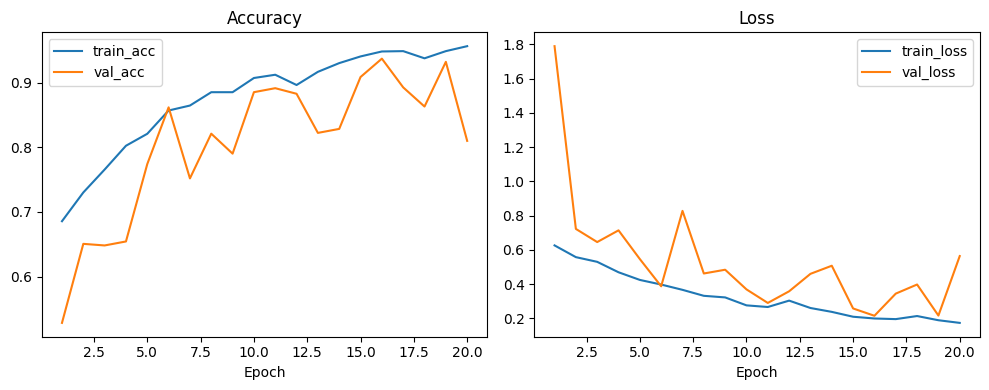

Loading best model from checkpoint...
Evaluating on test set...
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 720ms/step - accuracy: 0.9303 - loss: 0.2185
Test loss: 0.2027, Test accuracy: 0.9420
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1

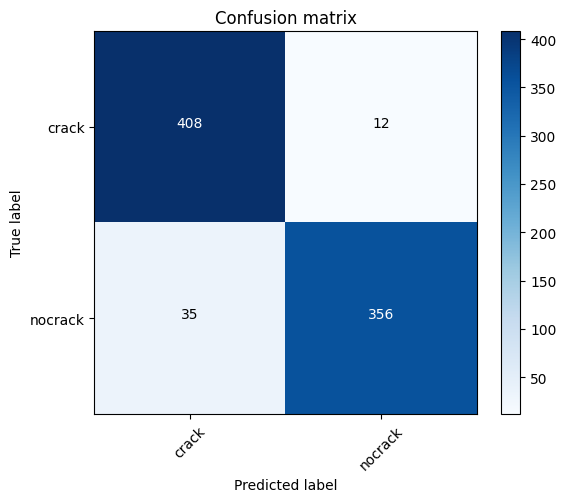

Classification report:
              precision    recall  f1-score   support

       crack       0.92      0.97      0.95       420
     nocrack       0.97      0.91      0.94       391

    accuracy                           0.94       811
   macro avg       0.94      0.94      0.94       811
weighted avg       0.94      0.94      0.94       811

Saved best model to: D:/MajorProject/best_crack_detector.keras
Also exported SavedModel to ./final_crack_detector_saved_model
Saved best model to: D:/MajorProject/best_crack_detector.keras
Also exported SavedModel to ./final_crack_detector_saved_model
Demo predictions on first 5 test images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
File: D:\MajorProject\data_land\nocrack\aug_2_20251101_090315.jpg -> {'label': 'nocrack', 'label_idx': 1, 'probability': 0.8080591559410095}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
File: D:\MajorProject\data_land\nocrack\aug_5_20250821_094547.jpg -> {'label': 'nocrack', 'label_idx': 1, 'probability': 0.9948586225509644}

In [65]:
# ---------- Main training pipeline ----------
def main():
    print("Listing images...")
    filepaths, labels, class_names = list_image_paths_and_labels(DATA_DIR)
    print(f"Found {len(filepaths)} images across classes: {class_names}")
    (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels) = train_val_test_split(
        filepaths, labels, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT, seed=SEED)
    print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")
        # Build datasets
    train_ds = prepare_dataset(train_paths, train_labels, BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, shuffle=True, augment=False)
    val_ds = prepare_dataset(val_paths, val_labels, BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, shuffle=False, augment=False)
    test_ds = prepare_dataset(test_paths, test_labels, BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, shuffle=False, augment=False)
    # Build model
    num_classes = len(class_names)
    model = build_custom_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=num_classes)
    model.summary()
    # Compile
    if num_classes == 2:
        loss = keras.losses.BinaryCrossentropy()
        metrics = ["accuracy"]
    else:
        loss = keras.losses.SparseCategoricalCrossentropy()
        metrics = ["accuracy"]
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # Callbacks
    checkpoint_cb = keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor="val_accuracy",
                                                    save_best_only=True, save_weights_only=False)
    reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    custom_earlystop = ConsecutiveDecreaseEarlyStopping(patience=PATIENCE_DECREASE_EPOCHS, monitor="val_accuracy")

    # Train
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[checkpoint_cb, reduce_lr, custom_earlystop]
    )

    # Plot training curves
    plot_history(history)

    # Load best model (in case subsequent epochs made it worse)
    print("Loading best model from checkpoint...")
    best_model = keras.models.load_model(MODEL_SAVE_PATH)

    # Evaluate on test set
    print("Evaluating on test set...")
    test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
    print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

    # Predictions for confusion matrix and classification report
    # Collect all test images and true labels
    y_true = []
    y_pred = []
    y_scores = []

    for x_batch, y_batch in test_ds:
        preds = best_model.predict(x_batch)
        if num_classes == 2:
            probs = preds.reshape(-1)
            preds_labels = (probs >= 0.5).astype(int)
            y_scores.extend(probs.tolist())
            y_pred.extend(preds_labels.tolist())
        else:
            probs = preds
            preds_labels = np.argmax(probs, axis=1)
            y_scores.extend(np.max(probs, axis=1).tolist())
            y_pred.extend(preds_labels.tolist())
        y_true.extend(y_batch.numpy().tolist())
        # Metrics
    acc = accuracy_score(y_true, y_pred)
    print(f"Final test accuracy (sklearn): {acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:")
    print(cm)
    plot_confusion_matrix(cm, class_names, normalize=False)
    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    # Save final model weights (already saved best); also save a copy called final_saved_model if desired
    best_model.save("final_crack_detector_saved_model.keras")  # SavedModel format
    print("Saved best model to:", MODEL_SAVE_PATH)
    print("Also exported SavedModel to ./final_crack_detector_saved_model")
        # Save final model weights (already saved best); also save a copy called final_saved_model if desired
    best_model.save("final_crack_detector_saved_model.keras")  # SavedModel format
    print("Saved best model to:", MODEL_SAVE_PATH)
    print("Also exported SavedModel to ./final_crack_detector_saved_model")
        # Provide prediction function
    def predict_image(image_path: str, model: keras.Model = best_model):
        """
        Loads an image from disk, preprocess, and returns predicted class and probability.
        """
        img = tf.io.read_file(image_path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
        img = tf.cast(img, tf.float32) / 255.0
        img = tf.expand_dims(img, axis=0)  # batch
        preds = model.predict(img)
        if num_classes == 2:
            prob = float(preds[0].squeeze())
            label_idx = int(prob >= 0.5)
            label = class_names[label_idx]
            return {"label": label, "label_idx": label_idx, "probability": prob}
        else:
            probs = preds[0]
            label_idx = int(np.argmax(probs))
            return {"label": class_names[label_idx], "label_idx": label_idx, "probability": float(np.max(probs))}

    # Demo predictions (first 5 test images)
    print("Demo predictions on first 5 test images:")
    demo_count = min(5, len(test_paths))
    for i in range(demo_count):
        res = predict_image(test_paths[i])
        print(f"File: {test_paths[i]} -> {res}")

    # Return trained artifacts if needed
    return {
        "model": best_model,
        "history": history,
        "test_results": {"loss": test_loss, "accuracy": test_acc},
        "class_names": class_names,
        "predict_fn": predict_image
    }


if __name__ == "__main__":
    artifacts = main()
